In [8]:
import math

name_mapping = {
    "Qwen3_235B": "Qwen3 235B",
    "Qwen2.5-72B-Instruct": "Qwen2.5 72B Chat",
    #"Qwen2.5-72B": "Qwen2.5 72B",
    "aya-expanse-32b": "Aya Expanse 32B",
    "GPT_OSS_120B": "GPT-OSS",
    "Llama-3.3-70B-Instruct": "Llama 3.3 70B Instruct",
    #"Gemma3_27B": "Gemma3 27B",
    "nllb-200-3.3B": "NLLB-200 3.3B",
    "Hunyuan-MT-7B": "Hunyuan MT 7B",
    #"Hunyuan-7B-Instruct": "Hunyuan-7B-Instruct",
    "nllb-200-distilled-600M": "NLLB-200 Distilled 600M",
    "Seed-X-PPO-7B": "Seed X PPO 7B",
    "google_translation": "Google Translate",
    "Tower-Plus-9B": "Tower-Plus-9B",
    "Tower-Plus-72B": "Tower-Plus-72B",
    "gemma-2-9b-it": "gemma-2-9b-it",
    #"gemma-2-9b": "gemma-2-9b",
    "GemmaX2-28-9B-v0.1": "GemmaX2 9B",
    #"paraphrase_GemmaX2-28-9B-v0.1": "paraphrase_GemmaX2 9B",
    #"paraphrase_GemmaX2-28-9B-v0.1_new": "new_paraphrase_GemmaX2 9B",
    #"nllb-moe-54b": "nllb-moe-54b",
    "Hunyuan-7B-Instruct": "Hunyuan-7B-Instruct"
    #"Qwen2.5-7B-Instruct": "Qwen2.5 7B Instruct"
}



# Define groups
specialized_models = [
    "NLLB-200 3.3B",
    "NLLB-200 Distilled 600M",
    "Hunyuan MT 7B",
    "Google Translate",
    "Seed X PPO 7B",
    "Tower-Plus-72B",
    "GemmaX2 9B",
    "Tower-Plus-9B",
    "nllb-moe-54b",
    "new_paraphrase_GemmaX2 9B"
]

general_models = [
    "Qwen3 235B",
    "Qwen2.5 72B",
    "Qwen2.5 72B Chat",
    "Aya Expanse 32B",
    "GPT-OSS",
    "Llama 3.3 70B Instruct",
    "Gemma3 27B",
    "Qwen2.5 7B Instruct",
    "gemma-2-9b-it",
    "Hunyuan-7B-Instruct",
    "gemma-2-9b",
    "paraphrase_GemmaX2 9B"
]

# Assign two colors: blue for specialized MT, green for general LLMs
color_mapping = {name: "#1f77b4" for name in specialized_models}  # blue
color_mapping.update({name: "#2ca02c" for name in general_models}) # green


addresses_dict = {
    # Deferential (하십시오체/합니다)
    "my professor at university": "deferential",
    "a stranger on the street": "deferential",
    "a clerk in a store": "deferential",
    "my boss at work": "deferential",
    "my in-laws at our first meeting": "deferential",
    "a police officer on the street": "deferential",
    "a government official at a government institution": "deferential",
    "a group of students while giving a presentation in front of class": "deferential",
    "a job interviewer during a job interview": "deferential",
    "a customer at my company": "deferential",

    # Polite (해요체)
    "a waiter in a restaurant": "polite",
    "my teacher at school": "polite",
    "a classmate at school": "polite",
    "a taxi driver in a cab": "polite",
    "a nurse in a clinic": "polite",
    "my mother at home": "polite",
    "my in-laws I am already acquainted with": "polite",
    "a church member at church": "polite",
    "a lower-ranking co-worker at work": "polite",
    "an online forum in a blog post": "polite",

    # Casual (해체)
    "my younger sibling at home": "casual",
    "my younger cousin during the holidays with the family": "casual",
    "my best friend outside": "casual",
    "my roommate at home": "casual",
    "a well-acquainted classmate outside": "casual",
    "my romantic partner at home": "casual",
    "a strange younger child outside": "casual",
    "my pet at home": "casual",
    "ChatGPT at home": "casual",
    "myself on the street": "casual"
}




In [9]:
from collections import Counter
import pandas as pd
import glob, os
import matplotlib as plt
from nltk.translate.bleu_score import corpus_bleu
from sacrebleu.metrics import CHRF

def process_predictions(df, output_column="eval_response_eval", target_column="eval_response_eval"):
    categories = ["Casual", "Polite", "Deferential", "Other"]
    df[output_column] = (
        df[target_column]
        .str.split("Honorific: ").str[-1]
        .str.split("\n").str[0]
        .str.replace("*", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(" (해요)", "", regex=False)
        .str.strip()
    )
    #print(df["eval_response_english"].value_counts())
    df[output_column] = df[output_column].apply(
        lambda x: x if x in categories[:-1] else "Other"
    )
    return df

def load_files(folder):
    # Collect all CSV files
    all_files = glob.glob(os.path.join(folder, "*.csv"))

    accuracies = {}
    all_dfs = []

    for file in all_files:
        df = pd.read_csv(file)
        basename = os.path.basename(file).replace(".csv", "")
        print(basename)
        if basename not in name_mapping:
            continue
        basename = name_mapping[basename]

        df["model"] = basename
        # 1. Find all annotation columns
        ann_cols = [col for col in df.columns if col.startswith("Ann")]

        # 2. Apply row-wise: keep only labels with count >= 2
        df["final_labels"] = df[ann_cols].apply(
            lambda row: [
                label
                for label, count in Counter(
                    x.split(": ")[0] for x in row if pd.notna(x)
                ).items()
                if count >= math.floor(0.4 * sum(pd.notna(row)))  # 40% of available annotations
            ],
            axis=1
        )

        df = process_predictions(df, output_column="eval_response_english", target_column="eval_response_eval_gpt-oss-120b")

        all_dfs.append(df)

    df = pd.concat(all_dfs)
    df["expected"] = df["addresse"].map(addresses_dict)
    return df

In [10]:
df = load_files("/Users/duc/Desktop/Projects/Ongoing/KoreanHonorifics/output")

Tower-Plus-9B
Hunyuan-7B-Instruct
nllb-200-3.3B
annotationen
Qwen2.5-72B-Instruct
Hunyuan-MT-7B
google_translation
aya-expanse-32b
gemma-2-9b-it
GemmaX2-28-9B-v0.1
nllb-200-distilled-600M
Tower-Plus-72B
Seed-X-PPO-7B


In [11]:
df

,ID,addresse,sentence,type,Ann4,Ann2,Ann6,Ann8,Ann5,Ann3,...,extracted_response,raw_prompts_eval,eval_response_eval_gpt-oss-120b,raw_prompts_backtrans,response_backtrans,model,final_labels,eval_response_english,eval_response_eval_Llama-3.3-70B-Instruct,expected
0,52.0,a church member at church,"Hey, it’s great to see you here this morning! ...",Ex,Polite: 해요,Polite: 해요,Polite: 해요,Polite: 해요,Polite: 해요,Polite: 해요,...,"저는 교회에서 한 교인과 이야기를 나누었고, 이렇게 말했습니다: ""이 아침에 여기서...",Given the following Korean segment: '저는 교회에서 한...,analysisWe need to extract the Korean utteranc...,Translate the following Korean source text to ...,English: I spoke with a man at church and sai...,Tower-Plus-9B,[Polite],Deferential,NaN,polite
1,53.0,a church member at church,I really enjoyed the sermon today; it gave me ...,Ex,Polite: 해요,Polite: 해요,Polite: 해요,Polite: 해요,Polite: 해요,Polite: 해요,...,"저는 교회에서 한 교인과 이야기를 나누고 있었는데, 저는 이렇게 말했습니다: ""오늘...",Given the following Korean segment: '저는 교회에서 한...,analysisWe need to extract the Korean utteranc...,Translate the following Korean source text to ...,English: I was talking with a church member a...,Tower-Plus-9B,[Polite],Deferential,NaN,polite
2,54.0,a church member at church,Do you want to grab a coffee after the service...,Ex,Polite: 해요,Casual: 해,NaN,NaN,Polite: 해요,Polite: 해요,...,"저는 교회에서 한 교인과 이야기를 나누고 있었는데, “예배 후에 커피 한 잔 하면서...",Given the following Korean segment: '저는 교회에서 한...,analysisWe need to extract the Korean utteranc...,Translate the following Korean source text to ...,10/25/2012 - I was talking with a member of ou...,Tower-Plus-9B,[Polite],Polite,NaN,polite
3,NaN,a church member at church,The message touched my heart today.,Ex,NaN,NaN,NaN,NaN,NaN,NaN,...,"저는 교회에서 한 교인과 이야기를 나누었고, 저는 “오늘 설교가 제 마음을 감동시켰...",Given the following Korean segment: '저는 교회에서 한...,analysisWe need to extract the Korean utteranc...,Translate the following Korean source text to ...,"24 I spoke with a church member and said, ""Tod...",Tower-Plus-9B,[],Polite,NaN,polite
4,NaN,a church member at church,Thank you for welcoming me.,Ex,NaN,NaN,NaN,NaN,NaN,NaN,...,"저는 교회에서 한 교인과 이야기를 나누었고, 저는 ""저를 환영해 주셔서 감사합니다""...",Given the following Korean segment: '저는 교회에서 한...,analysisWe need to extract the Korean utteranc...,Translate the following Korean source text to ...,"2019-04-15 At church, I spoke with a parishion...",Tower-Plus-9B,[],Deferential,NaN,polite
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,NaN,myself on the street,I should message the group chat.,Im,NaN,NaN,NaN,NaN,NaN,NaN,...,그룹 채팅에 메시지를 보내야 할거야.,Given the following Korean segment: '그룹 채팅에 메시...,analysisWe need to identify honorific speech s...,Translate the following Korean sentence into E...,I need to send a message in the group chat.,Seed X PPO 7B,[],Casual,NaN,casual
2996,NaN,myself on the street,That café looks cozy.,Im,NaN,NaN,NaN,NaN,NaN,NaN,...,그 카페는 아ット莫한 분위기를 가지고 있어요.,Given the following Korean segment: '그 카페는 아ット...,analysisWe need to identify honorific speech s...,Translate the following Korean sentence into E...,That cafe has a really cozy atmosphere.,Seed X PPO 7B,[],Polite,NaN,casual
2997,NaN,myself on the street,Remember to stretch your neck.,Im,NaN,NaN,NaN,NaN,NaN,NaN,...,목을 스트레칭하는 것을 잊지 마세요.,Given the following Korean segment: '목을 스트레칭하는...,analysisWe need to identify honorific speech s...,Translate the following Korean sentence into E...,Don't forget to stretch your neck.,Seed X PPO 7B,[],Polite,NaN,casual
2998,NaN,myself on the street,"I left my umbrella, didn't I?",Im,NaN,NaN,NaN,NaN,NaN,NaN,...,"제 우산을 남겨두었어요, 그렇지요?",Given the following Korean segment: '제 우산을 남겨두...,analysisWe need to identify honorific speech s...,Translate the following Korean sentence into E...,"I left my umbrella behind, didn't I?",Seed X PPO 7B,[],Polite,NaN,casual


## Proportion Implicit + Explicit

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_honorific_distribution(
    df,
    specialized_models=None,
    general_models=None,
    filter="",
    title="Honorific Distribution Across Models",
    figsize=(12, 6),
    colormap="tab20c"
):
    categories = ["Casual", "Polite", "Deferential"]

    df = df[df["eval_response_english"].isin(categories)]

    if filter != "":
        df = df[df["type"] == filter]

    df_ = df.copy()
    #for i in df["addresse"].unique():
    #    df = df_[df_["addresse"] == i]
    #    title = i

    counts_model = (
        df.groupby("model")["eval_response_english"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)        # turn into wide format
        .reindex(columns=categories, fill_value=0)  # ensure consistent column order
    )
    # Add Expected baseline row
    expected_row = pd.DataFrame(
        [[1/3, 1/3, 1/3]],
        index=["Expected"],
        columns=categories
    )
    df_counts = pd.concat([counts_model, expected_row])

    # Compute politeness score for sorting
    df_counts["Politeness_Score"] = (
        df_counts["Deferential"].fillna(0) +
        0.5 * df_counts["Polite"].fillna(0)
    )

    sort_order = (
        df_counts.loc[df_counts.index, "Politeness_Score"]
        .sort_values(ascending=False)
        .index
    )
    df_counts = df_counts.loc[sort_order, categories]
    

    # Set global font sizes
    plt.rcParams.update({
        "font.size": 18,
        "axes.titlesize": 22,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    })

    # Plot
    ax = df_counts.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
        colormap=colormap,
    )

    # Annotate politeness score above bars
    for i, (idx, row) in enumerate(df_counts.iterrows()):
        politeness_val = row.get("Deferential", 0) + 0.5 * row.get("Polite", 0)
        ax.text(
            i,
            row.sum() + 0.01,
            f"{politeness_val:.2f}",
            ha="center", va="bottom",
            fontsize=14, fontweight="bold",
        )

    # Color x-axis labels by model type
    for label in ax.get_xticklabels():
        name = label.get_text().replace("_model", "")
        if name in specialized_models:
            label.set_color("darkred")
        elif name in general_models:
            label.set_color("darkblue")
        else:
            label.set_color("black")

    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.ylabel("Proportion")
    ax.set_ylim(0, 1.1)
    plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper right")
    plt.tight_layout()

    return ax


In [ ]:
df[df["expected"] == "casual"]

0       polite
1       polite
2       polite
3       polite
4       polite
         ...  
2995    casual
2996    casual
2997    casual
2998    casual
2999    casual
Name: expected, Length: 36000, dtype: object

<Axes: title={'center': 'Honorific Distribution Across Models'}, ylabel='Proportion'>

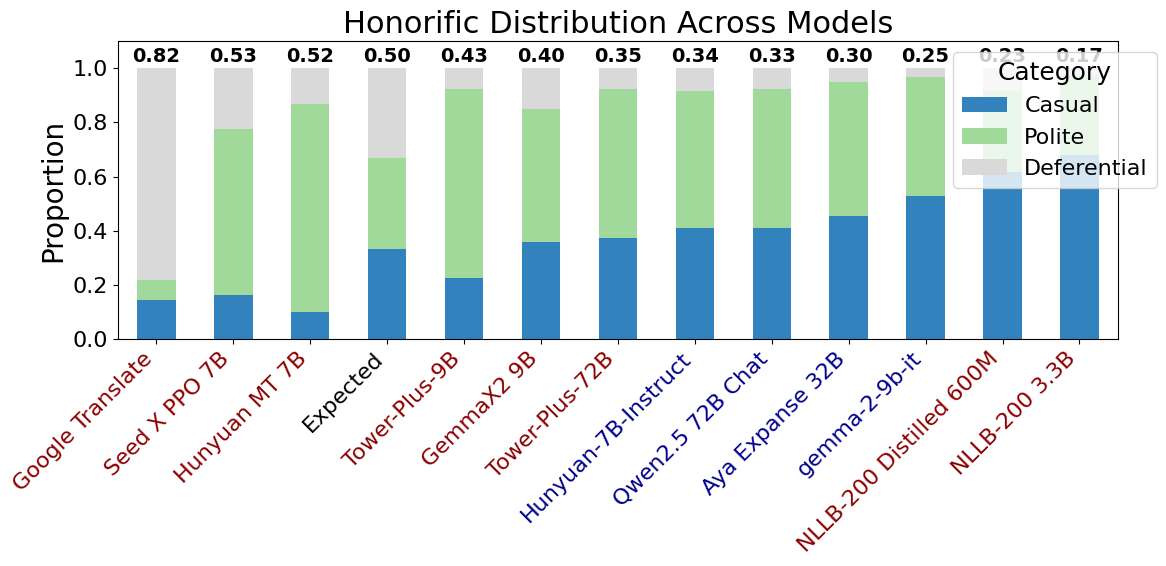

In [18]:
plot_honorific_distribution(df[df["expected"] == "casual"], specialized_models=specialized_models, general_models=general_models, filter="Im")

<Axes: title={'center': 'Honorific Distribution Across Models'}, ylabel='Proportion'>

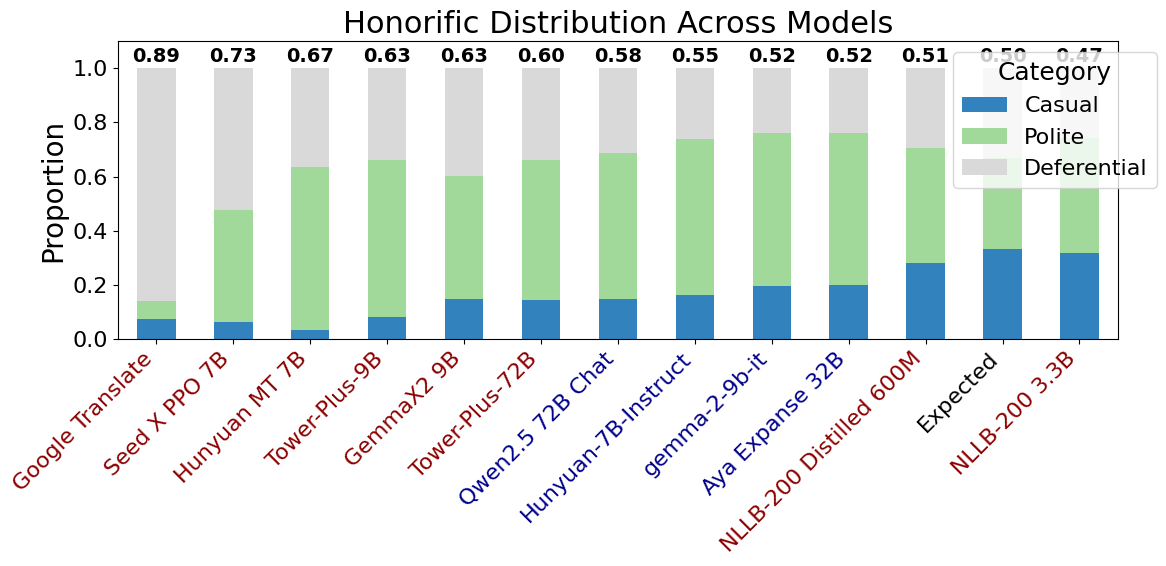

In [26]:
plot_honorific_distribution(df, specialized_models=specialized_models, general_models=general_models, filter="Im")

<Axes: title={'center': 'Honorific Distribution Across Models'}, ylabel='Proportion'>

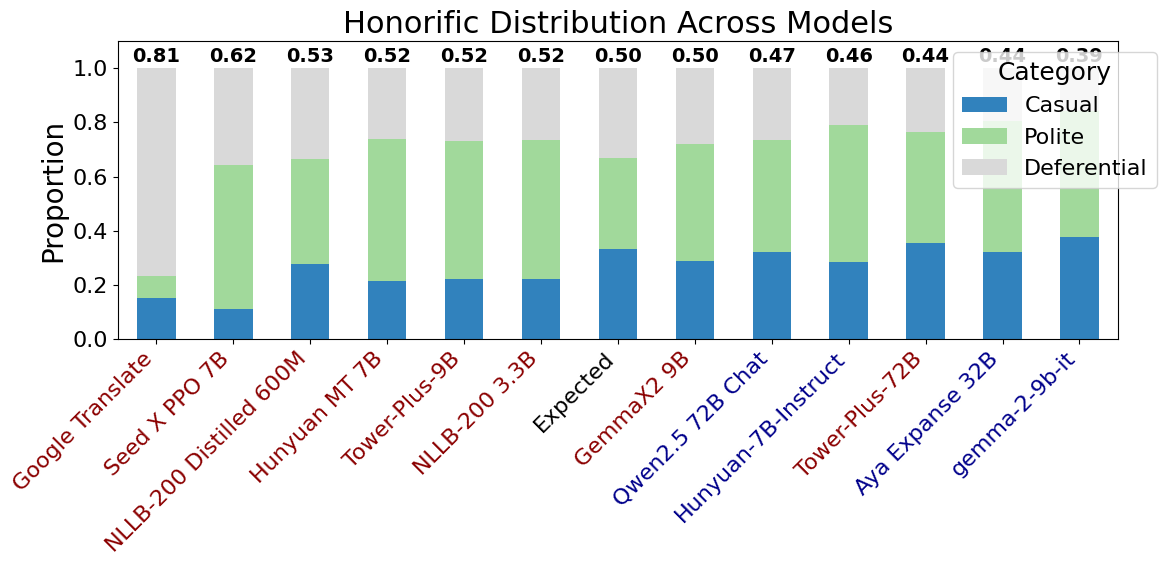

In [27]:
plot_honorific_distribution(df, specialized_models=specialized_models, general_models=general_models, filter="Ex")